In [1]:
### Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

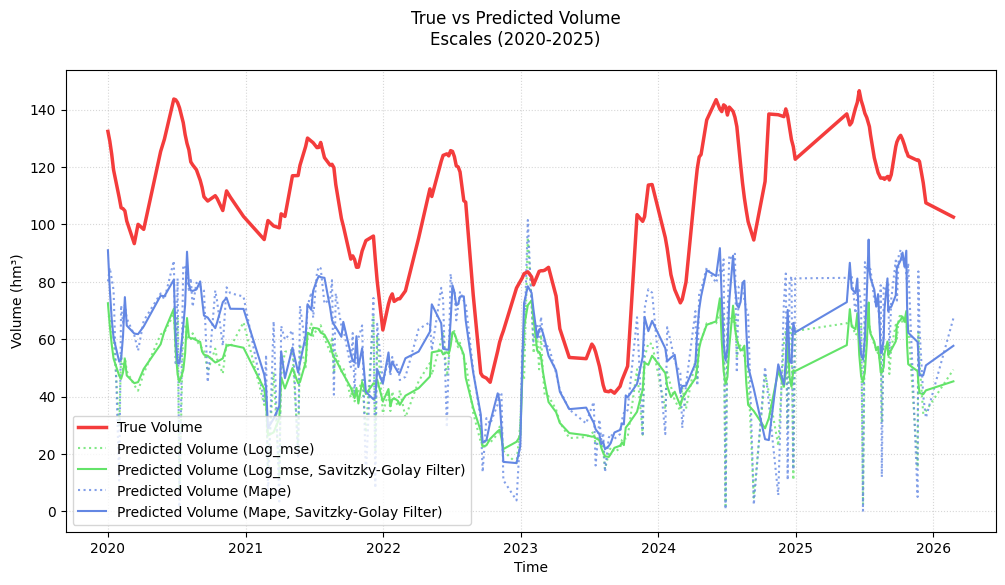

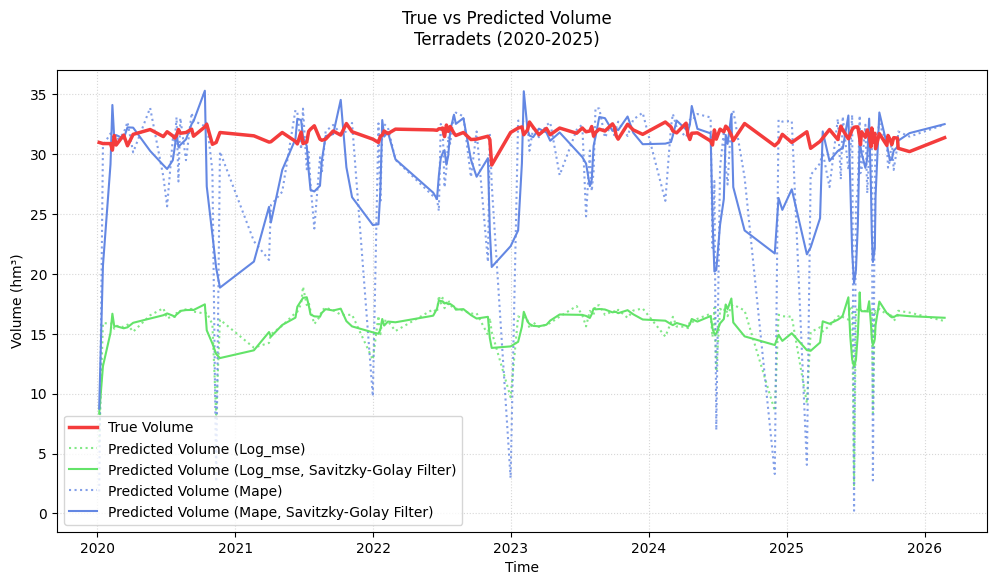

In [13]:
# Generate visualizations

dams = ['escales', 'terradets']
losses = ['log_mse', 'mape']
colors = {
    "log_mse": "#63E369",
    "mape": "#6387E3"
}

for dam in dams:
    plt.figure(figsize=(12,6))
    first = True
    
    for loss in losses:
        data = pd.read_csv(f'../output/tables/ensemble_{loss}_predictions_{dam}.csv')
        data['date'] = pd.to_datetime(data['date'])

        if(first):
            plt.plot(data['date'], data['true_volume'], color="#F43C3C", label='True Volume', zorder=10, linewidth=2.5)
            first = False

        plt.plot(data['date'], data['raw_pred'], color=colors[loss], label=f'Predicted Volume ({loss.capitalize()})', linestyle=':', alpha=0.8)
        plt.plot(data['date'], data['smooth_pred'], color=colors[loss], label=f'Predicted Volume ({loss.capitalize()}, Savitzky-Golay Filter)', linestyle='-', zorder=5)


    plt.xlabel('Time')
    plt.ylabel('Volume (hm³)')
    plt.suptitle(f'True vs Predicted Volume\n{dam.capitalize()} (2020-2025)')

    plt.grid(True, alpha=0.5, linestyle=':')
    years = sorted(data['date'].dt.year.unique())
    ticks = pd.to_datetime([f"{y}-01-01" for y in years])

    plt.xticks(ticks, years)
    plt.legend(loc='lower left')
    plt.savefig(f'../output/figs/predictions_{dam}.png', dpi=800)
    plt.show()